In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


In [5]:
# Generate housing-like dataset — no internet needed
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

np.random.seed(42)
n = 20640

df = pd.DataFrame({
    'MedInc':      np.random.uniform(0.5, 15, n),
    'HouseAge':    np.random.uniform(1, 52, n),
    'AveRooms':    np.random.uniform(1, 10, n),
    'AveBedrms':   np.random.uniform(1, 5, n),
    'Population':  np.random.uniform(3, 35682, n),
    'AveOccup':    np.random.uniform(1, 10, n),
    'Latitude':    np.random.uniform(32, 42, n),
    'Longitude':   np.random.uniform(-124, -114, n),
})

# Price based on income + house age (realistic relationship)
df['Price'] = (
    df['MedInc'] * 0.4 +
    df['AveRooms'] * 0.1 -
    df['AveBedrms'] * 0.05 +
    np.random.normal(0, 0.5, n)
).clip(0.5, 5.0)

print("Shape:", df.shape)
print(df.head())

Shape: (20640, 9)
      MedInc   HouseAge  AveRooms  AveBedrms    Population  AveOccup  \
0   5.930832  18.043376  9.579131   3.228731  11675.630589  5.589788   
1  14.285357  18.898620  1.579316   3.206299  33163.433545  8.056332   
2  11.113912   3.631730  1.258544   1.080089  29041.436753  3.770910   
3   9.180548   7.073811  2.575269   4.083625  11961.902645  7.844708   
4   2.762270  10.851426  9.361763   4.642963  24769.492932  2.624430   

    Latitude   Longitude     Price  
0  40.495323 -117.734954  3.026883  
1  33.471218 -121.662006  5.000000  
2  40.625112 -118.289958  4.961043  
3  37.601416 -116.678928  3.288357  
4  32.439046 -119.343461  2.024329  


In [6]:
print("Dataset Info:")
print(df.info())
print("\nStatistics:")
print(df.describe())
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       7.743433     26.469346      5.495059      3.006634  17742.525874   
std        4.182018     14.698748      2.592404      1.150372  10327.972127   
min        0.500169      1.000282      1.000076      1.000520   

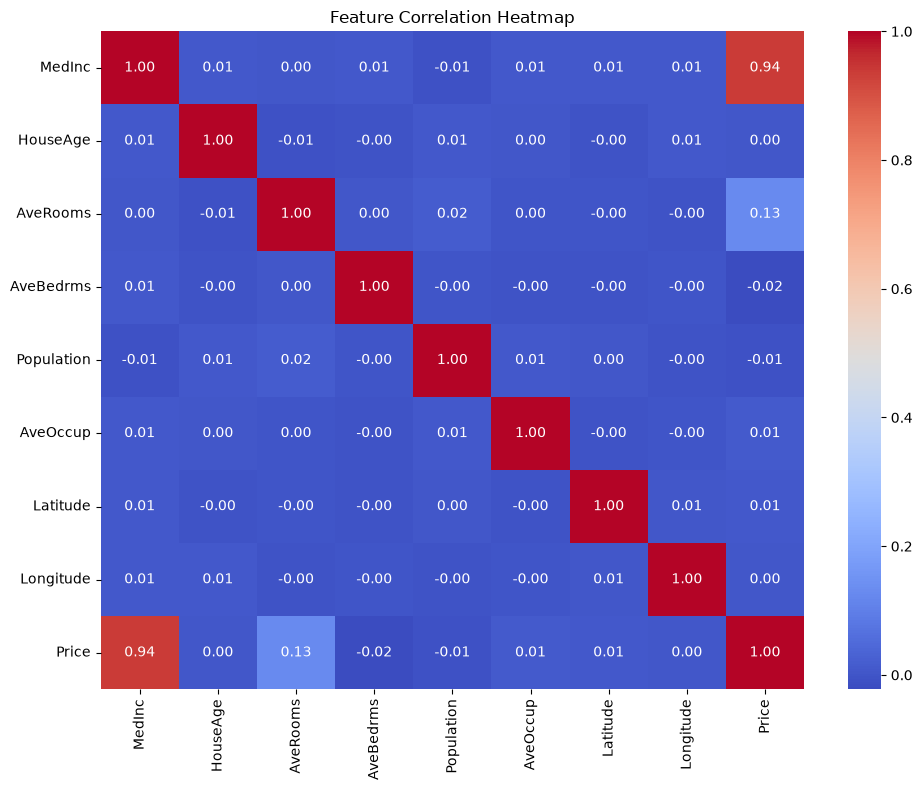

Heatmap saved!


In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()
print("Heatmap saved!")

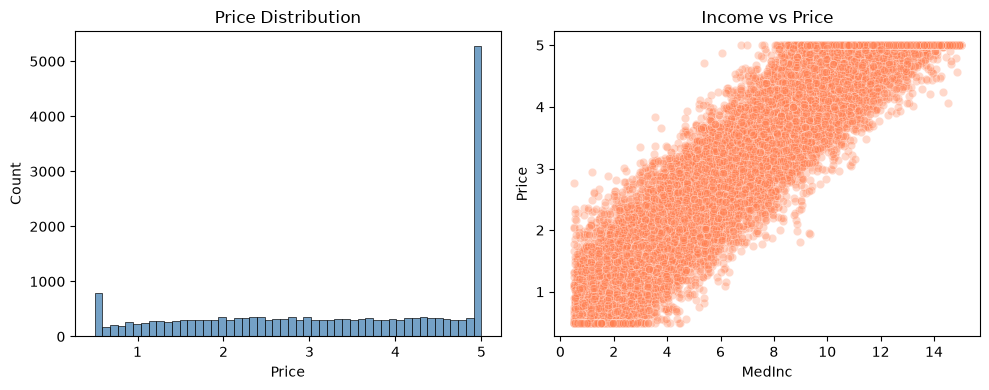

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Price'], bins=50, color='steelblue')
plt.title("Price Distribution")

plt.subplot(1,2,2)
sns.scatterplot(x=df['MedInc'], y=df['Price'], alpha=0.3, color='coral')
plt.title("Income vs Price")

plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

In [9]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16512, 8)
Test size: (4128, 8)


In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{name} → RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

Linear Regression → RMSE: 0.4844 | MAE: 0.3931 | R2: 0.8914
Ridge Regression → RMSE: 0.4844 | MAE: 0.3931 | R2: 0.8914
Random Forest → RMSE: 0.4342 | MAE: 0.3161 | R2: 0.9128
XGBoost → RMSE: 0.4442 | MAE: 0.3291 | R2: 0.9087


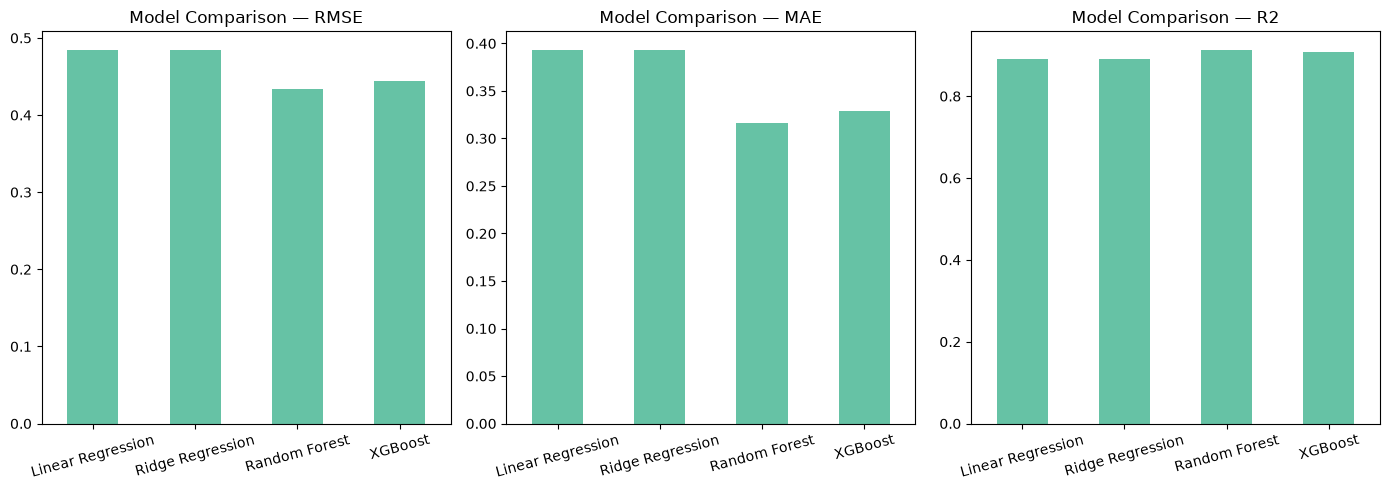

Chart saved!


In [11]:
results_df = pd.DataFrame(results).T
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    results_df[metric].plot(kind='bar', ax=axes[i], colormap='Set2', legend=False)
    axes[i].set_title(f"Model Comparison — {metric}")
    axes[i].set_xticklabels(results_df.index, rotation=15)

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()
print("Chart saved!")

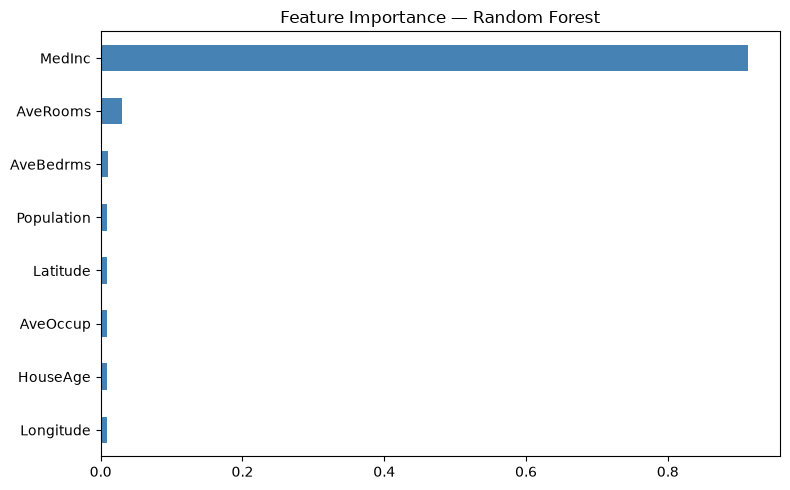

Done!


In [13]:
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)

feature_names = df.drop('Price', axis=1).columns.tolist()

feat_imp = pd.Series(best_model.feature_importances_, index=feature_names)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
print("Done!")

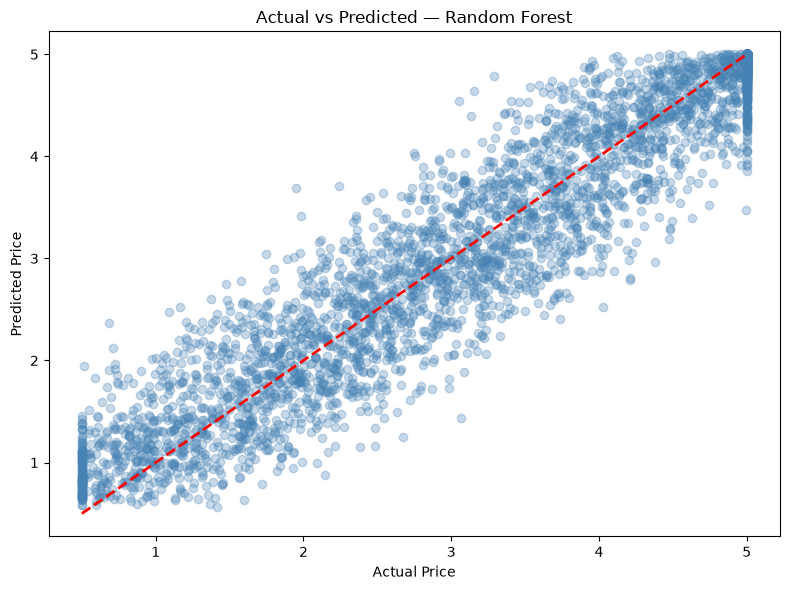

Done!


In [14]:
preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted — Random Forest")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()
print("Done!")

In [15]:
import pickle

with open("housing_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("housing_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!
